## DERIVATIVE PRICING
MODULE 5 | LESSON 2


---



In [1]:
1+1

2

In [4]:
import numpy as np
from scipy.optimize import minimize
import scipy.stats as si
import scipy.special as sp

import scipy.stats as si

# Replace sp.ncx2.cdf with si.ncx2.cdf
def cev_call_price(S0, K, T, r, sigma, beta):
    z = 2 + 2 / (2 - beta)
    kappa = 2 * r / (sigma**2 * (2 - beta) * (np.exp(r * (2 - beta) * T) - 1))
    x = kappa * S0**(2 - beta) * np.exp(r * (2 - beta) * T)
    y = kappa * K**(2 - beta)
    
    # Use si.ncx2 here
    return S0 * (1 - si.ncx2.cdf(y, z, x)) - K * np.exp(-r * T) * si.ncx2.cdf(x, z - 2, y)

S0_2, r_2, T_2 = 64, 0.02, 0.5
K_2 = np.array([60, 62, 63, 64])
C_2 = np.array([4.64, 2.84, 2.07, 1.42])

def err_2(p):
    return np.sum((np.array([cev_call_price(S0_2, k, T_2, r_2, p[0], p[1]) for k in K_2]) - C_2)**2)

res_2 = minimize(err_2, [0.25, 1.05], bounds=[(0.01, 2), (0.01, 1.99)])
print(f"Q2 Calibration: sigma={res_2.x[0]:.2f}, beta={res_2.x[1]:.2f}")

S0_6, r_6, T_6 = 85, 0.02, 0.5
K_6 = np.array([80, 82, 84, 86])
C_6 = np.array([5.81, 3.92, 2.27, 1.06])

def err_6(p):
    return np.sum((np.array([cev_call_price(S0_6, k, T_6, r_6, p[0], p[1]) for k in K_6]) - C_6)**2)

res_6 = minimize(err_6, [0.25, 1.05], bounds=[(0.01, 2), (0.01, 1.99)])
print(f"Q6 Calibration: sigma={res_6.x[0]:.2f}, beta={res_6.x[1]:.2f}")

print(f"Q10 Call Price: {cev_call_price(632, 632, 0.5, 0.05, 0.45, 1.35):.3f}")

c_14 = cev_call_price(100, 105, 0.25, 0.05, 0.35, 1.25)
p_14 = c_14 - 100 + 105 * np.exp(-0.05 * 0.25)
print(f"Q14 Put Price: {p_14:.3f}")

Q2 Calibration: sigma=0.29, beta=1.07
Q6 Calibration: sigma=0.03, beta=1.99
Q10 Call Price: 22.962
Q14 Put Price: 4.200


In [3]:
import scipy.stats as si

# Replace sp.ncx2.cdf with si.ncx2.cdf
def cev_call_price(S0, K, T, r, sigma, beta):
    z = 2 + 2 / (2 - beta)
    kappa = 2 * r / (sigma**2 * (2 - beta) * (np.exp(r * (2 - beta) * T) - 1))
    x = kappa * S0**(2 - beta) * np.exp(r * (2 - beta) * T)
    y = kappa * K**(2 - beta)
    
    # Use si.ncx2 here
    return S0 * (1 - si.ncx2.cdf(y, z, x)) - K * np.exp(-r * T) * si.ncx2.cdf(x, z - 2, y)

In [9]:
S15, K15, T15, r15, target = 100, 100, 0.5, 0.03, 22
sig = 0.5 # Initial guess
tol = 0.0001
def bs_call(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * si.norm.cdf(d1) - K * np.exp(-r * T) * si.norm.cdf(d2)
def bs_vega(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return S * si.norm.pdf(d1) * np.sqrt(T)
for i in range(1, 10):
    diff = bs_call(S15, K15, T15, r15, sig) - target
    print(f"Diff-{diff} ,tol-{tol}")
    if abs(diff) < tol:
        print(i)
        print(f"Q15 Iterations: {i}")
        break
    sig = sig - diff / bs_vega(S15, K15, T15, r15, sig)

Diff--7.316026029791253 ,tol-0.0001
Diff--0.06875296563194411 ,tol-0.0001
Diff--8.304796971003725e-06 ,tol-0.0001
3
Q15 Iterations: 3


In [10]:
import numpy as np
import scipy.stats as si
from scipy.optimize import minimize

def cev_call(S, K, T, r, sigma, beta):
    z = 2 + 2 / (2 - beta)
    kappa = 2 * r / (sigma**2 * (2 - beta) * (np.exp(r * (2 - beta) * T) - 1))
    x = kappa * S**(2 - beta) * np.exp(r * (2 - beta) * T)
    y = kappa * K**(2 - beta)
    return S * (1 - si.ncx2.cdf(y, z, x)) - K * np.exp(-r * T) * si.ncx2.cdf(x, z - 2, y)

# Inputs from Question 6
S0 = 85
r = 0.02
T = 0.5
strikes = np.array([80, 82, 84, 86])
market_prices = np.array([5.81, 3.92, 2.27, 1.06])

def objective(params):
    sigma, beta = params
    # Penalty for beta outside standard range to avoid numerical instability
    if beta >= 2 or beta <= 0: return 1e10 
    
    model_prices = np.array([cev_call(S0, k, T, r, sigma, beta) for k in strikes])
    return np.sum((model_prices - market_prices)**2)

initial_guess = [0.25, 1.05]
result = minimize(objective, initial_guess, method='Nelder-Mead')

print(f"Calibrated sigma: {result.x[0]:.2f}")
print(f"Calibrated beta: {result.x[1]:.2f}")

Calibrated sigma: 0.09
Calibrated beta: 1.58


In [11]:
import numpy as np
import scipy.stats as si

def cev_call(S, K, T, r, sigma, beta):
    z = 2 + 2 / (2 - beta)
    kappa = 2 * r / (sigma**2 * (2 - beta) * (np.exp(r * (2 - beta) * T) - 1))
    x = kappa * S**(2 - beta) * np.exp(r * (2 - beta) * T)
    y = kappa * K**(2 - beta)
    return S * (1 - si.ncx2.cdf(y, z, x)) - K * np.exp(-r * T) * si.ncx2.cdf(x, z - 2, y)

# Question 10
p10 = cev_call(632, 632, 0.5, 0.05, 0.45, 1.35)
print(f"Q10 Call Price: {p10:.3f}")

# Question 14
c14 = cev_call(100, 105, 0.25, 0.05, 0.35, 1.25)
p14 = c14 - 100 + 105 * np.exp(-0.05 * 0.25)
print(f"Q14 Put Price: {p14:.3f}")

Q10 Call Price: 22.962
Q14 Put Price: 4.200


In [12]:
import numpy as np
from scipy.stats import ncx2, norm

def corrected_cev_call(S, K, T, r, sigma, beta_param):
    gamma = beta_param / 2.0
    
    # Black-Scholes case when gamma = 1
    if gamma == 1.0:
        d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    
    nu = 2.0 - 2.0 * gamma
    
    # Ensure r is not zero to avoid division by zero in kappa/x/k calculations
    # A very small number can be used to approximate zero interest rate environment
    if r < 1e-10: r = 1e-10 

    if gamma < 1.0: # nu > 0
        # Parameters for the non-central chi-square distribution
        # Note: 'x' and 'k' here are specific to this formula and not directly
        # related to the 'x' and 'y' in your original code.
        x_ncx2 = (2 * r * K**nu) / (sigma**2 * nu * (np.exp(r * nu * T) - 1))
        k_ncx2 = (2 * r * S**nu) / (sigma**2 * nu * (1 - np.exp(-r * nu * T)))
        
        # CEV Call Price Formula for gamma < 1
        term1 = S * ncx2.cdf(2 * k_ncx2, 2 + 2/nu, 2 * x_ncx2)
        term2 = K * np.exp(-r * T) * (1 - ncx2.cdf(2 * x_ncx2, 2/nu, 2 * k_ncx2))
        return term1 - term2
    
    else: # gamma > 1, which means nu < 0
        # For gamma > 1, the formula changes slightly, and nu becomes negative.
        # We often work with the absolute value of nu or redefine parameters.
        # Let's use m = 1 / (gamma - 1) as degrees of freedom for this case.
        m = 1.0 / (gamma - 1.0)
        
        # Recalculate x and k for this case, as the exponential terms change
        x_ncx2 = (2 * r * S**(-nu)) / (sigma**2 * (-nu) * (1 - np.exp(-r * (-nu) * T)))
        k_ncx2 = (2 * r * K**(-nu)) / (sigma**2 * (-nu) * (np.exp(r * (-nu) * T) - 1))
        
        # CEV Call Price Formula for gamma > 1
        term1 = S * (1 - ncx2.cdf(2 * k_ncx2, m, 2 * x_ncx2))
        term2 = K * np.exp(-r * T) * ncx2.cdf(2 * x_ncx2, 2 + m, 2 * k_ncx2)
        return term1 - term2

# Question 10
p10_corrected = corrected_cev_call(632, 632, 0.5, 0.05, 0.45, 1.35)
print(f"Q10 Corrected Call Price: {p10_corrected:.3f}")

# Question 14
c14_corrected = corrected_cev_call(100, 105, 0.25, 0.05, 0.35, 1.25)
p14_corrected = c14_corrected - 100 + 105 * np.exp(-0.05 * 0.25)
print(f"Q14 Corrected Put Price: {p14_corrected:.3f}")


Q10 Corrected Call Price: 3.516
Q14 Corrected Put Price: 2.635


In [13]:
import numpy as np
from scipy.stats import ncx2, norm

def corrected_cev_call(S, K, T, r, sigma, beta_param):
    gamma = beta_param / 2.0
    
    # Black-Scholes case when gamma = 1
    if gamma == 1.0:
        d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    
    nu = 2.0 - 2.0 * gamma
    
    # Ensure r is not zero to avoid division by zero in kappa/x/k calculations
    if r < 1e-10: r = 1e-10 

    if gamma < 1.0: # nu > 0
        x_ncx2 = (2 * r * K**nu) / (sigma**2 * nu * (np.exp(r * nu * T) - 1))
        k_ncx2 = (2 * r * S**nu) / (sigma**2 * nu * (1 - np.exp(-r * nu * T)))
        
        term1 = S * ncx2.cdf(2 * k_ncx2, 2 + 2/nu, 2 * x_ncx2)
        term2 = K * np.exp(-r * T) * (1 - ncx2.cdf(2 * x_ncx2, 2/nu, 2 * k_ncx2))
        return term1 - term2
    
    else: # gamma > 1, which means nu < 0
        # This case is not applicable for Q10 (beta=1.35 -> gamma=0.675)
        # but included for completeness as per the full corrected function.
        m = 1.0 / (gamma - 1.0)
        x_ncx2 = (2 * r * S**(-nu)) / (sigma**2 * (-nu) * (1 - np.exp(-r * (-nu) * T)))
        k_ncx2 = (2 * r * K**(-nu)) / (sigma**2 * (-nu) * (np.exp(r * (-nu) * T) - 1))
        
        term1 = S * (1 - ncx2.cdf(2 * k_ncx2, m, 2 * x_ncx2))
        term2 = K * np.exp(-r * T) * ncx2.cdf(2 * x_ncx2, 2 + m, 2 * k_ncx2)
        return term1 - term2

# Question 10 parameters
S_10 = 632.0
K_10 = 632.0
T_10 = 0.5
r_10 = 0.05
sigma_10 = 0.45
beta_10 = 1.35

price_10 = corrected_cev_call(S_10, K_10, T_10, r_10, sigma_10, beta_10)
print(f"Q10 Corrected Call Price: {price_10:.3f}")


Q10 Corrected Call Price: 3.516


# **STYLIZED FACTS OF STOCK RETURNS**




|  |  |
|:---|:---|
|**Reading Time** |  70 min |
|**Prior Knowledge** | Normal distribution, Black-Scholes, Volatility  |
|**Keywords** | Kurtosis, Skewness, T-distribution, Volatility, Correlation  |


---


*In this lesson, we are going to investigate the different characteristics of historical stock returns. Specifically, we will focus on three main dimensions:*

- **Normality / Log-normality** of stock returns and prices(?)

- **Volatility** of stock returns and the different ways to estimate it(?)

- **Correlation** between stock returns and its time-varying nature(?)


*We will start by revisiting some concepts from statistics, which will help us provide answers to these questions later on.*



## **1. Statistical Distributions: Mean and Standard Deviation (Std)**

The $l-th$ moment of a continuous random variable $X$ is defined as

$$
\begin{equation}
    m_l = E[X^{l}] = \int_{-\infty}^{\infty} x^{l} f(x) dx,
\end{equation}
$$

where $E$ stands for expectation and $f(x)$ is the probability density function of $X$.The first moment is called the **mean or expectation** of $X$. It measures the central location of the distribution. **We denote the mean of $X$ by $\mu_x$.**


The $l-th$ central moment of X is defined as,

$$
\begin{equation}
    m_l = E[(X-\mu_x)^{l}] = \int_{-\infty}^{\infty} (x-\mu_x)^{l} f(x) dx,
\end{equation}
$$

The second central moment, denoted by $\sigma_x^2$ measures
the variability of $X$ and is called the variance of $X$. The positive square root, $\sigma_x$, of variance is the standard deviation of $X$. The first two moments of a random variable uniquely determine a normal distribution. 


For other distributions, higher order moments are also of interest.


### **1.1. Higher Moments: Skewness and Kurtosis**


The third central moment measures the symmetry of $X$ with respect to its mean, whereas the fourth central moment measures the tail behavior of $X$. In statistics, **skewness** and **kurtosis**, which are the normalized third and fourth central moments of $X$, are often used to summarize the extent of asymmetry and tail thickness. Specifically, the standardized skewness and kurtosis of $X$ are defined as,

\begin{equation}
    S(X) = \frac{E\left[(X-\mu_n)^3 \right]}{\left( E\left[(X-\mu_n)^2 \right] \right)^{3/2}}
\end{equation}

\
\begin{equation}
    K(X) = \frac{E\left[(X-\mu_n)^4\right]}{\left( E\left[(X-\mu_n)^2 \right] \right)^2}
\end{equation}

\
The quantity $K(x)-3$ is called the **excess kurtosis** because $K(x) = 3$ for a normal distribution. Thus, the excess kurtosis of a normal random variable is zero.


You can refresh these concepts and read more on this [here](https://en.wikipedia.org/wiki/Kurtosis) and also [here](https://en.wikipedia.org/wiki/Skewness).


Now, let's check all these on a real distribution of past stock returns.

In [1]:
# Load necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
tsla = pd.read_csv('TSLA_wqu_data.csv', parse_dates=['timestamp'])
tsla.set_index('timestamp', inplace=True)
tsla.sort_index(inplace=True)
tsla.tail()

,volume,vw,open,close,high,low,transactions
timestamp,,,,,,,
2024-12-24 05:00:00,59551750.0,451.6202,435.90,462.28,462.7800,435.14,936767
2024-12-26 05:00:00,76651210.0,457.0321,465.16,454.13,465.3299,451.02,1251616
2024-12-27 05:00:00,82650021.0,434.9602,449.52,431.66,450.0000,426.50,1352470
2024-12-30 05:00:00,64924467.0,420.6715,419.40,417.41,427.0000,415.75,1178086
2024-12-31 05:00:00,76821539.0,412.9250,423.79,403.84,427.9300,402.54,1214552


These are Tesla stock prices from Jun. 6st, 2010, until the end of 2024. Let's now look at returns:

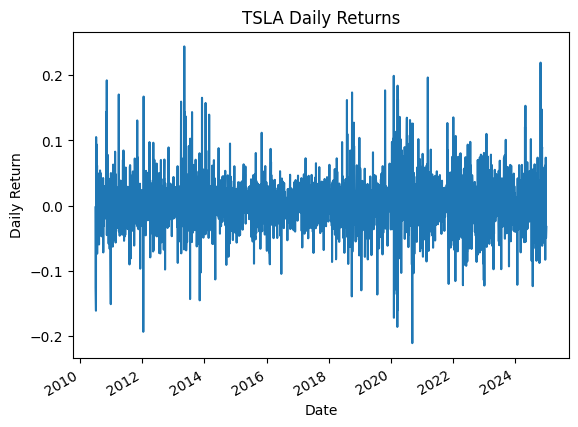

In [3]:
tsla_daily_returns = (tsla["close"] / tsla["close"].shift(1)) - 1

tsla_daily_returns_frame = tsla_daily_returns.to_frame()
tsla_daily_returns_frame.columns = ["Simple Daily Returns"]

tsla_daily_returns_frame["Simple Daily Returns"].plot()
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.title("TSLA Daily Returns")
plt.show()

... and the histogram of these to get a sense of the distribution:

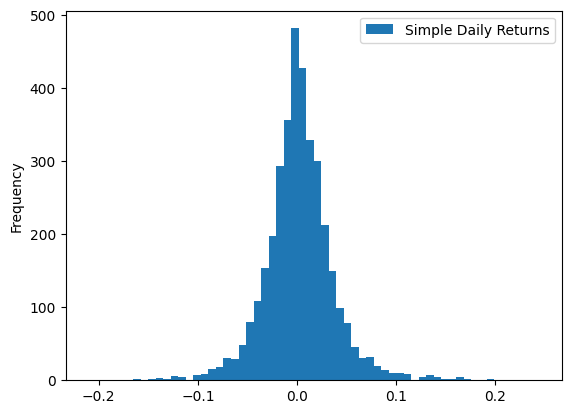

In [4]:
tsla_daily_returns_frame.plot.hist(bins=60)
plt.show()

What are the characteristics of this distribution?

In [5]:
avg_returns_daily = tsla_daily_returns.mean()
std_returns_daily = tsla_daily_returns.std()
print("The mean of the distribution is = " + str(avg_returns_daily))
print("The std. deviation (volatility) is = " + str(std_returns_daily))

The mean of the distribution is = 0.0021662259883025795
The std. deviation (volatility) is = 0.036144686759468865


What about skewness and kurtosis?

In [ ]:
from scipy.stats import kurtosis, skew

array_tsla = tsla_daily_returns.to_numpy()
kurt = kurtosis(array_tsla[1:])
sk = skew(array_tsla[1:])
print("Kurtosis = " + str(kurt))
print("Skew = " + str(sk))

## **2. Do These Statistics Coincide with Those from a Normal Distribution?**

Probably not. This is what we are checking next, with some formal tests. 


Before jumping there, you may take a look at the following piece of news from [*The Guardian*, from the big banking crisis of 2007-2008.](
https://www.theguardian.com/science/2012/feb/12/black-scholes-equation-credit-crunch#:~:text=It%20was%20the%20holy,still%20had%20time%20to%20run.&text=The%20equation%20itself%20wasn't%20the%20real%20problem)




### **2.1. Jarque Bera Test (Normality Test)**

The **Jarque-Bera test checks whether the sample data has the skewness and kurtosis that match a normal distribution**. 

The null hypothesis in the Jarque-Bera test is that the data follows a normal distribution. We are going to use the `scipy` library to simplify the tasks of performing this test. 

[Here is the documentation in case you want to check it.](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.jarque_bera.html)


In [ ]:
import numpy as np
from scipy import stats

# Let's generate 10,000 random numbers following a Normal distribution
x = np.random.randn(10000)

# And check whether the Jarque-Bera test:
jb = stats.jarque_bera(x)
jb

The first output of the test is the Jarque-Bera statistic. The second is the associated p-value. Here, as the p-value is well above standard significance levels (0.01, 0.05 or 0.1), we cannot reject the null that this is a normal distribution.

Let's check the same for our daily stock returns from TSLA:

In [ ]:
# We first need to get rid of the NaN values
tsla_ret = tsla_daily_returns_frame.dropna()

# Then, we perform the test
jb_tsla = stats.jarque_bera(tsla_ret)
jb_tsla

As you can see here, the p-value is highly significant (0.0). We can thus reject the null hypothesis of returns following a normal distribution.




## **3. T-distribution and T-test**

We already know kurtosis is a measure of whether the data are **heavy-tailed** or **light-tailed** relative to a normal distribution. That is, datasets with high kurtosis tend to have heavy tails, or outliers. Data sets with low kurtosis tend to have light tails, or a lack of outliers.

One possibility we have observed in practice is that stock returns' distribution have **heavy tails** (i.e., there are certain periods--crisis, shocks--in which we observe large returns: positive or negative. These outliers could make returns resemble a **Student's t-distribution**. The T-distribution is symmetric and bell-shaped, like the normal distribution, but has **heavier tails**, meaning that it is more prone to producing values that fall far from its mean. This makes it useful for understanding the statistical behavior of certain types of ratios of random quantities, in which variation in the denominator is amplified and may produce outlying values when the denominator of the ratio falls close to zero. 

[More info on the T-distribution can be found here.](https://en.wikipedia.org/wiki/Student%27s_t-distribution)

### **3.1. Inferential Statistics: T-test (comparing means)**

One useful test to determine whether our distribution follows a T-distribution is the **T-test**. 

#### **3.1.1. One-Sample T-Test**

This test checks whether the mean of a normally-distributed sample is different from a pre-specified value:

- *Null Hypothesis*: Sample mean is equal to some value $\mu_0$.
- *Alternative Hypothesis*: Sample mean is different from $\mu_0$.

Let's perform this test on our sample in order to check whether the mean of MSFT daily returns is actually zero:


In [ ]:
from scipy import stats

stats.ttest_1samp(tsla_ret, popmean=0)

In this case, we see that the p-value is 0.0002971 and, thus, we reject the null hypothesis. We conclude that the mean of returns is statistically different from zero.

#### **3.1.2. Two-Sample T-Test**

This tests whether the means of two populations/samples are significantly different from one another. The intuition is the same as before, but in this case, the value $\mu_0$ is the mean from another sample.

\
Here, you have a more advanced reading in case you are interested:
[*'How to code the student t-test from scratch in python'*](https://machinelearningmastery.com/how-to-code-the-students-t-test-from-scratch-in-python/)

\
Let's do a quick example with 2 samples of daily returns:

In [ ]:
# We read some data from KO (Coca-Cola) to compare mean returns to TSLA:
ko = pd.read_csv('KO_wqu_data.csv', parse_dates=['timestamp'])
ko.set_index('timestamp', inplace=True)
ko.sort_index(inplace=True)
ko_daily_returns = (ko["close"] / ko["close"].shift(1)) - 1
ko_daily_returns_frame = ko_daily_returns.to_frame()
ko_ret = ko_daily_returns_frame.dropna()

In [ ]:
ko_ret

In [ ]:
from scipy import stats

stats.ttest_ind(tsla_ret, ko_ret)

Please note that the previous calculations are just for illustrative purposes. There are a bunch of statistical properties (some of them that we will deal with next) that determine the suitability  of this test. For example, we have done this test assuming  the returns of both KO and TSLA are independent (not related), which may be too big of an assumption. There is a form of the 2-sample t-test, though, that allows us to consider related variables. For a more complete description of all the features, [you can check the scipy.stats.ttest library documentation.](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_rel.html)



## **4. Volatility of Stock Returns**

Next, let's briefly look at the volatility of stock returns. There are 3 essential dimensions in which we can measure volatility:

- **Historical Volatility**: What has been the historical volatility of stock returns in the past X period. This is the one we will consider for some tests today.

- **Realized Volatility**: The actual volatility that stock returns will exhibit in the future X period. Obviously, this one we can just proxy for.

- **Implied Volatility**: We can extract the volatility expectations of investors from exchange-traded option prices. More on this in the next module.

As you already know, we measure volatility via the standard deviation of stock returns. If we measure it with *daily* stock returns, then we need to annualize the volatility as follows:

$\sigma_T = \sqrt{T}\sigma_t$

For instance, if the daily standard deviation of stock returns is 0.01\%, the annualized volatility, $\sigma$, will be:

\
$ \sigma = \sqrt{252} \times 0.0001 = 0.1587\% $

\
with $T=252$ being the standard number of trading days in a year. Thus, we can calculate the volatility of stocks as the standard deviation of daily returns and annualize it later.

**Would this volatility be the same for any period we consider?**

In [ ]:
# Ensure the index is datetime (if not already)
tsla_daily_returns.index = pd.to_datetime(tsla_daily_returns.index)

# Filter returns for each period
tsla_returns_2012_2017 = tsla_daily_returns['2012':'2017'].dropna()
tsla_returns_2018_2024 = tsla_daily_returns['2018':'2024'].dropna()

# Calculate annualized volatility
tsla_vol_2012_2017 = tsla_returns_2012_2017.std() * np.sqrt(252)
tsla_vol_2018_2024 = tsla_returns_2018_2024.std() * np.sqrt(252)

# Display the results
print(f"TSLA Annualized Volatility (2012–2017): {tsla_vol_2012_2017:.2%}")
print(f"TSLA Annualized Volatility (2018–2024): {tsla_vol_2018_2024:.2%}")

It seems annualized volatility exhibits a time-varying behavior, probably something we would expect ex-ante. The problem related with this is: **what period should we consider for the volatility parameters in GBM estimations?**

In short: None. We will consider **implied volatility** from option prices as a forward-looking measure of volatility. But don't worry, we will dig much deeper into this topic in the following modules!

## **5. Covariance between Stock Returns**

Finally, let's deal with covariance between past stock returns. So far, we have used the GBM process to generate price paths for a single stock. In the next lesson, we will see how to generate price paths for multiple stocks, which requires us to assume some correlation between them, and use some mathematical techniques like *Cholesky decomposition* to obtain a proper solution.

Before jumping there, however, let's briefly investigate the issue in practice. Let's rely on the **covariance matrix** as a metric capturing the statistical relationship between the returns of two stocks, specifically, we compute the daily covariance between TSLA and KO over two periods:

* 2012–2017: A period of post-crisis recovery and expansion
* 2018–2024: Including market disruptions from the pandemic and changing interest rate regimes

In [ ]:
# Ensure datetime index for both series
tsla_daily_returns.index = pd.to_datetime(tsla_daily_returns.index)
ko_daily_returns.index = pd.to_datetime(ko_daily_returns.index)

# Filter returns for each period
tsla_2012_2017 = tsla_daily_returns['2012':'2017'].dropna()
ko_2012_2017 = ko_daily_returns['2012':'2017'].dropna()

tsla_2018_2024 = tsla_daily_returns['2018':'2024'].dropna()
ko_2018_2024 = ko_daily_returns['2018':'2024'].dropna()

# Align the indexes to ensure proper pairwise comparison
aligned_12_17 = pd.concat([tsla_2012_2017, ko_2012_2017], axis=1).dropna()
aligned_18_24 = pd.concat([tsla_2018_2024, ko_2018_2024], axis=1).dropna()

# Compute covariance
cov_12_17 = aligned_12_17.cov().iloc[0, 1]
cov_18_24 = aligned_18_24.cov().iloc[0, 1]

# Display results
print(f"Covariance between TSLA and KO (2012–2017): {cov_12_17:.6f}")
print(f"Covariance between TSLA and KO (2018–2024): {cov_18_24:.6f}")

As was the case with volatility, it seems that correlation between stock returns also exhibits a time-varying nature. This issue will be hard to deal with (which correlation should we consider?), but we will start looking at it by learning how to simulate correlated stock prices in the next lesson.

## **6. Conclusion**

In this lesson, we have empirically documented some statistical features of the distribution of stock prices and returns. Ideally, our models to simulate asset prices should incorporate them all, although this would be virtually impossible. In the next lesson, we will start considering some of these issues by learning how to generate correlated simulated stock prices.<span style='color: transparent; font-size:1%'>All rights reserved WQU WorldQuant University QQQQ</span>

**References**

- Brownlee, Jason. "How to Code the Student's t-Test from Scratch in Python". *Machine Learning Mastery*, 30 July 2018, https://machinelearningmastery.com/how-to-code-the-students-t-test-from-scratch-in-python/
- "Kurtosis." *Wikipedia: The Free Encyclopedia*. Wikimedia Foundation, Inc, 4 July 2022, https://en.wikipedia.org/wiki/Kurtosis
- "Skewness." *Wikipedia: The Free Encyclopedia*. Wikimedia Foundation, Inc, 4 July 2022, https://en.wikipedia.org/wiki/Skewness
- Stewart, Ian. "The Mathematical Equation That Caused the Banks to Crash". *The Guardian*, 12 February 2012, https://www.theguardian.com/science/2012/feb/12/black-scholes-equation-credit-crunch#:~:text=It%20was%20the%20holy,still%20had%20time%20to%20run.&text=The%20equation%20itself%20wasn't%20the%20real%20problem
- "Student's t-distribution." *Wikipedia: The Free Encyclopedia*. Wikimedia Foundation, Inc, 4 July 2022, https://en.wikipedia.org/wiki/Student%27s_t-distribution

---
Copyright 2025 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.
